# Verification of TNF–TNFR1 sequential binding

This notebook verifies the curated reconstruction of Figure 1b in McMillan et al. (2021), *Nature Communications* 12:582, DOI [10.1038/s41467-020-20828-3](https://doi.org/10.1038/s41467-020-20828-3).

The verification has two independent levels:

1. Run both curated BNGL files with BioNetGen and compare their seven-dose equilibrium scans with a separately written four-state occupancy ODE.
2. Compare the BNGL predictions at the paper's reported dissociation constants with the exact IMS-MS fractions in the publisher's Source Data workbook, sheet `Fig 1b`.

No curves were digitized. The committed CSV files preserve the tabulated source values.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

MODEL_DIR = Path.cwd()
if MODEL_DIR.name != "tnf_tnfr1_sequential_binding_mcmillan2021":
    MODEL_DIR = Path("models/tnf_tnfr1_sequential_binding_mcmillan2021").resolve()
REFERENCE = MODEL_DIR / "reference"
BNGPATH = Path(os.environ.get("BNGPATH", Path.home() / "Simulations/BioNetGen-2.9.3"))
BNG2 = BNGPATH / "BNG2.pl"
assert BNG2.exists(), f"BioNetGen executable not found: {BNG2}"

DOSES_NM = np.array([1000., 2000., 4000., 6000., 8000., 10000., 23000.])
TNF_NM = 5000.0
KOFF = 0.01
CONDITIONS = {
    "Apo TNF": {
        "model": "tnf_tnfr1_sequential_binding_mcmillan2021.bngl",
        "data": "mcmillan2021_fig1b_apo.csv",
        "kd": np.array([0.01, 0.02, 0.22]),
    },
    "TNF + UCB-0595": {
        "model": "tnf_tnfr1_sequential_binding_mcmillan2021_ucb0595.bngl",
        "data": "mcmillan2021_fig1b_ucb0595.csv",
        "kd": np.array([0.04, 0.19, 9612.0]),
    },
}
print(f"BioNetGen: {BNG2}")

Matplotlib is building the font cache; this may take a moment.


BioNetGen: /Users/wish/Simulations/BioNetGen-2.9.3/BNG2.pl


## Run BioNetGen

Each BNGL file is copied into a temporary directory and executed there, so verification does not alter the committed reference outputs. The active BNGL protocol starts with 5 µM free TNF and each reported TNFR1 dose, integrates for 10,000 s, and records the 0R–3R occupancy populations.

In [2]:
def read_scan(path):
    with path.open() as handle:
        names = handle.readline().lstrip("#").split()
    values = np.loadtxt(path)
    columns = {name: values[:, i] for i, name in enumerate(names)}
    total = columns["TNF_all"]
    fractions = np.column_stack([columns[f"TNF_{i}R"] / total for i in range(4)])
    return columns["TNFR1_conc"], fractions


def run_bionetgen(model_name):
    source = MODEL_DIR / model_name
    with tempfile.TemporaryDirectory(prefix="mcmillan2021_") as tmp:
        work = Path(tmp)
        local_model = work / source.name
        shutil.copy2(source, local_model)
        environment = os.environ.copy()
        environment["BNGPATH"] = str(BNGPATH)
        completed = subprocess.run(
            ["perl", str(BNG2), local_model.name],
            cwd=work,
            env=environment,
            check=True,
            capture_output=True,
            text=True,
        )
        scan = work / f"{local_model.stem}_scan.scan"
        assert scan.exists(), completed.stdout + completed.stderr
        return read_scan(scan)


bng_results = {}
for condition, specification in CONDITIONS.items():
    doses, fractions = run_bionetgen(specification["model"])
    np.testing.assert_allclose(doses, DOSES_NM, rtol=0, atol=1e-9)
    bng_results[condition] = fractions
    print(condition, "completed:", fractions.shape)

Apo TNF completed: (7, 4)


TNF + UCB-0595 completed: (7, 4)


## Independent occupancy ODE

Let $T_i$ be TNF with $i$ bound receptors and $R$ free TNFR1, all in nM. Because the BNGL model names three equivalent sites explicitly, the macroscopic forward multiplicities are 3, 2, and 1, while the reverse multiplicities are 1, 2, and 3:

egin{align}
v_{1+}&=3(k_\mathrm{off}/K_{d1})T_0R, & v_{1-}&=k_\mathrm{off}T_1,\
v_{2+}&=2(k_\mathrm{off}/K_{d2})T_1R, & v_{2-}&=2k_\mathrm{off}T_2,\
v_{3+}&=(k_\mathrm{off}/K_{d3})T_2R, & v_{3-}&=3k_\mathrm{off}T_3.
\end{align}

These equations are implemented directly below; they do not parse or reuse the generated BioNetGen network.

In [3]:
def occupancy_rhs(_time, state, kd):
    t0, t1, t2, t3, receptor = state
    v1f = 3.0 * (KOFF / kd[0]) * t0 * receptor
    v1r = KOFF * t1
    v2f = 2.0 * (KOFF / kd[1]) * t1 * receptor
    v2r = 2.0 * KOFF * t2
    v3f = (KOFF / kd[2]) * t2 * receptor
    v3r = 3.0 * KOFF * t3
    return [
        -v1f + v1r,
        v1f - v1r - v2f + v2r,
        v2f - v2r - v3f + v3r,
        v3f - v3r,
        -v1f + v1r - v2f + v2r - v3f + v3r,
    ]


def independent_scan(kd):
    rows = []
    for dose in DOSES_NM:
        solution = solve_ivp(
            occupancy_rhs,
            (0.0, 10000.0),
            [TNF_NM, 0.0, 0.0, 0.0, dose],
            args=(kd,),
            method="BDF",
            rtol=1e-10,
            atol=1e-11,
        )
        assert solution.success, solution.message
        rows.append(solution.y[:4, -1] / TNF_NM)
    return np.asarray(rows)


independent_results = {
    condition: independent_scan(specification["kd"])
    for condition, specification in CONDITIONS.items()
}

MODEL_TOLERANCE = 2e-6
for condition in CONDITIONS:
    error = np.abs(bng_results[condition] - independent_results[condition])
    print(f"{condition}: BioNetGen vs independent max abs error = {error.max():.3g}")
    assert error.max() < MODEL_TOLERANCE

Apo TNF: BioNetGen vs independent max abs error = 1.36e-09
TNF + UCB-0595: BioNetGen vs independent max abs error = 1.22e-09


## Comparison with the reported Figure 1b data

The paper reports affinity estimates to one or two significant digits and the Source Data occupancy fractions to 0.001. The model-specification comparison above is therefore held to a strict absolute tolerance of $2	imes10^{-6}$. Agreement with the experiment is reported descriptively as RMSE and maximum absolute residual, because the workbook supplies one rounded fraction per state and dose, with no uncertainty estimates. This evaluates the authors' published parameterization rather than silently refitting it.

In [4]:
reported_results = {}
metrics = {}
for condition, specification in CONDITIONS.items():
    table = np.genfromtxt(REFERENCE / specification["data"], delimiter=",", names=True)
    reported = np.column_stack([table[f"Frac_TNF_{i}R"] for i in range(4)])
    reported_results[condition] = reported
    residual = bng_results[condition] - reported
    metrics[condition] = {
        "rmse": float(np.sqrt(np.mean(residual**2))),
        "max_abs": float(np.max(np.abs(residual))),
        "sse": float(np.sum(residual**2)),
    }
    print(
        f"{condition}: RMSE={metrics[condition]['rmse']:.5f}, "
        f"max abs residual={metrics[condition]['max_abs']:.5f}, "
        f"SSE={metrics[condition]['sse']:.5f}"
    )

Apo TNF: RMSE=0.07239, max abs residual=0.16586, SSE=0.14671
TNF + UCB-0595: RMSE=0.06700, max abs residual=0.17348, SSE=0.12568


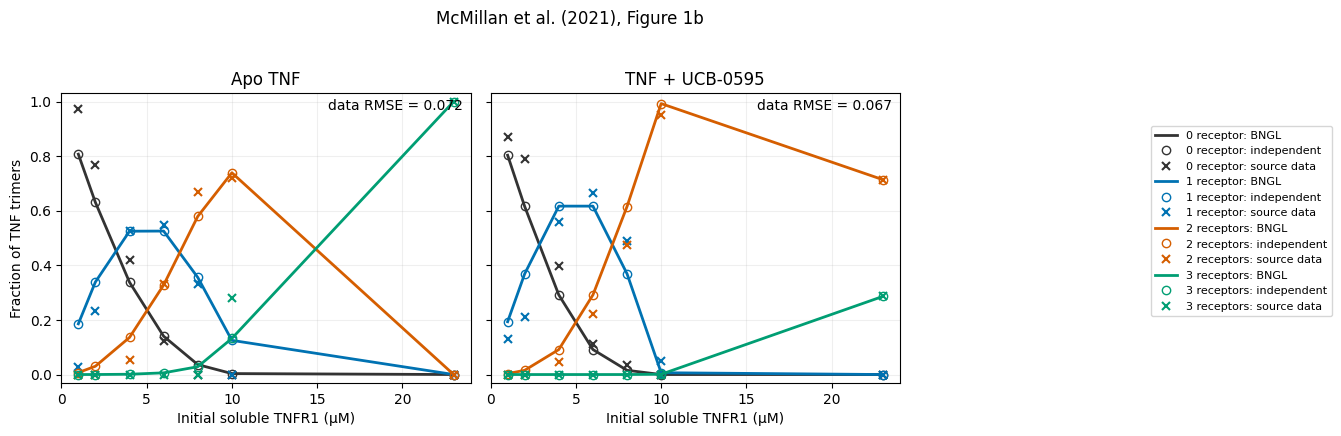

Saved verify_mcmillan2021.png


In [5]:
colors = ["#333333", "#0072B2", "#D55E00", "#009E73"]
state_labels = ["0 receptor", "1 receptor", "2 receptors", "3 receptors"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)

for axis, condition in zip(axes, CONDITIONS):
    x = DOSES_NM / 1000.0
    for state, (color, label) in enumerate(zip(colors, state_labels)):
        axis.plot(x, bng_results[condition][:, state], color=color, lw=2, label=f"{label}: BNGL")
        axis.plot(
            x,
            independent_results[condition][:, state],
            linestyle="none",
            marker="o",
            ms=6,
            markerfacecolor="none",
            markeredgecolor=color,
            label=f"{label}: independent",
        )
        axis.plot(
            x,
            reported_results[condition][:, state],
            linestyle="none",
            marker="x",
            ms=6,
            mew=1.5,
            color=color,
            label=f"{label}: source data",
        )
    axis.set_title(condition)
    axis.set_xlabel("Initial soluble TNFR1 (µM)")
    axis.set_xlim(0, 24)
    axis.set_ylim(-0.03, 1.03)
    axis.grid(alpha=0.2)
    axis.text(
        0.98,
        0.98,
        f"data RMSE = {metrics[condition]['rmse']:.3f}",
        ha="right",
        va="top",
        transform=axis.transAxes,
    )

axes[0].set_ylabel("Fraction of TNF trimers")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, ncol=1)
fig.suptitle("McMillan et al. (2021), Figure 1b")
fig.tight_layout(rect=(0, 0, 0.80, 0.95))
output = MODEL_DIR / "verify_mcmillan2021.png"
fig.savefig(output, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved {output.name}")

## Result

The strict model-specification test passes when the maximum absolute difference between BioNetGen and the independently implemented occupancy ODE is below $2	imes10^{-6}$ across both conditions, all seven receptor doses, and all four occupancy states. The second comparison quantifies how the paper's rounded, reported affinity estimates reproduce the official Figure 1b experimental fractions; its residuals are shown rather than treated as numerical implementation error.